In [183]:
import os
import re
import zipfile
import urllib.request
from collections import Counter
from spellchecker import SpellChecker
import re

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, GRU, Dropout, Bidirectional, SpatialDropout1D, Conv1D, MaxPooling1D, LSTM
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize


from tokenizers import normalizers
from tokenizers.normalizers import NFD, StripAccents, Lowercase

# Download NLTK resources
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


In [184]:
# Configure GPU - use only GPU 0
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Optionally limit GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f'Using GPU: {gpus[0].name}')
    except RuntimeError as e:
        print(e)
else:
    print('No GPU available, using CPU')


No GPU available, using CPU


In [185]:
# checkimg data if exist
os.path.exists('../data/GrammarandProductReviews.csv') 

True

In [ ]:
df = pd.read_csv('../data/GrammarandProductReviews.csv')
df.head()

In [ ]:
# Drop rows without ratings first, "subset = filter" 
df_clean = df.dropna(subset=['reviews.rating']).copy()
df_clean['rating'] = df_clean['reviews.rating'].astype(int)

# Shift scores
score_min = df_clean['rating'].min()
# print(df_clean['rating'])
# print(score_min)
df_clean['score_shifted'] = df_clean['rating'] - score_min
# print(df_clean['score_shifted'])
df_clean.head()

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc,last_char,ends_correctly,rating,score_shifted
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.02537E+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,Joshua,6.02537E+11,.,True,5,4
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,Good flavor. This review was collected as part...,Good,NaN,NaN,Dorothy W,73416000391,.,True,5,4
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,Good flavor.,Good,NaN,NaN,Dorothy W,73416000391,.,True,5,4
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,I read through the reviews on here before look...,Disappointed,NaN,NaN,Rebecca,67981934427,.,True,1,0
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,Walker557,67981934427,.,True,1,0


### 1.EDA

#### 1.1.Do reviewers use punctuation correctly?

In [ ]:
#  Clean trailing spaces and grab the last character
# We use .astype(str) to ensure no errors with empty reviews
# To use specialized string functions (like slicing or stripping),
#  you must "unlock" the string toolkit by adding .str.
# .astype(str): Makes the data a string.
# .str: Tells Pandas: "I’m about to do a string operation on every row in this column

# .str.strip()
# This does not get rid of the last letter; it removes "whitespace" (invisible spaces, tabs, or newlines)
# from the very beginning and very end of the text.
df_clean['last_char'] = df_clean['reviews.text'].astype(str).str.strip().str[-1]
# print(df['last_char'])

# Code Piece                 Action,                   "Result on ""Great!  """
# .astype(str),        Changes type to string,          """Great!  """
# .str.strip(),        Removes end spaces,               """Great!"""
# .str[-1],            Grabs the last character,          """!"""

# Define valid punctuation
valid_punc = ['.', '!', '?']

# Check if the last character is valid
df_clean['ends_correctly'] = df['last_char'].isin(valid_punc)
# print(df['ends_correctly'])
# Get the count of those who DON'T use it correctly
incorrect_count = len(df) - df['ends_correctly'].sum()
proportion = (incorrect_count / len(df)) * 100

print(f"Number of reviews missing end punctuation: {incorrect_count}")
print(f"Percentage of incorrect punctuation: {proportion:.2f}%")

0         True
1         True
2         True
3         True
4         True
         ...  
71039     True
71040     True
71041    False
71042     True
71043     True
Name: ends_correctly, Length: 71044, dtype: bool
Number of reviews missing end punctuation: 12692
Percentage of incorrect punctuation: 17.86%


#### 1.2.Does the number of spelling errors differ by rating?

In [ ]:
spell = SpellChecker()
#re.findall(r'\b\w+\b', ...) ==> Think of this as a magnet that only picks up letters and numbers, leaving everything else (punctuation) behind.
# Input: "The food was grate!!"   ==> Output: ['the', 'food', 'was', 'grate']

def count_spelling_errors(text):
    # Removing punctuation and numbers, keeping only words so , i can check only words
    words = re.findall(r'\b\w+\b', str(text).lower())
    
    # finding which words are not in spell list which mean all the dataset
    misspelled = spell.unknown(words)
    
    return len(misspelled)



df_sample = df_clean.head(500).copy()
df_sample['spelling_errors'] = df_sample['reviews.text'].apply(count_spelling_errors)

# Group by rating and find the average
spelling_trend = df_sample.groupby('rating')['spelling_errors'].mean()

print("Average Spelling Errors by Rating:")
print(spelling_trend)

Average Spelling Errors by Rating:
rating
1    0.714286
2    0.750000
3    0.666667
4    0.517857
5    0.653495
Name: spelling_errors, dtype: float64


#### 1.3.What is the distribution of star ratings across products?

In [ ]:
# getting brands(products)
top_10_products = df_clean['brand'].value_counts().nlargest(10).index


# Calculate the AVERAGE rating for those specific brands
# We group by brand and then take the mean of the rating
top_10_averages = df_clean.groupby('brand')['rating'].mean().loc[top_10_products]
# top_10_products
top_10_averages  



brand
Clorox                  4.825421
Universal Home Video    4.663807
Tide                    4.168091
FOX                     4.107603
Disney                  4.722914
Olay                    4.193567
Warner Home Video       4.349550
L'Oreal Paris           4.352218
L'oreal Paris           4.495629
Sony Pictures           4.357242
Name: rating, dtype: float64

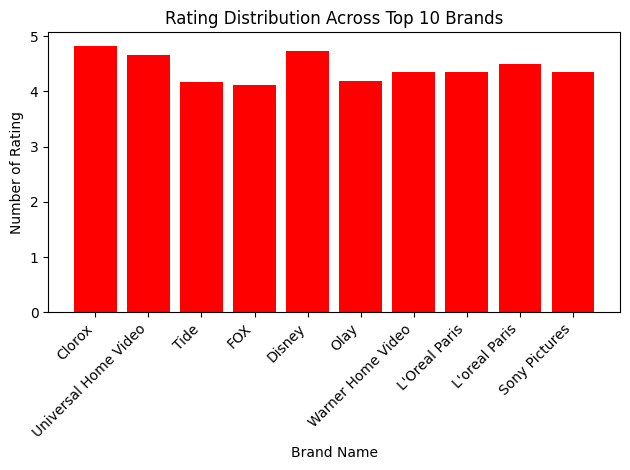

In [ ]:
# 4. Plot it
plt.bar(top_10_products, top_10_averages , color='red')
plt.title('Rating Distribution Across Top 10 Brands')
plt.xlabel('Brand Name')
plt.ylabel('Average of Rating')
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()

### 2.Preprocess the dataset by :

#### 2.1.Generating a binary target variable from ratings (positive / negative sentiment)

In [ ]:
# creating binary target
# If rating is greater than 3, it becomes 1 (Positive). Otherwise, it becomes 0 (Negative)
# astye(int) --> this return true false to 1,0 
df_clean['target'] = (df_clean['rating'] > 3).astype(int)


# See how many of each we have
print("\nTarget Distribution:")
print(df_clean['target'].value_counts())


Target Distribution:
target
1    61141
0     9903
Name: count, dtype: int64


#### 2.2.Clean the Data - Common NLP Data Cleaning Techniques -

##### 2.2.1.Normalizing the Texts ("Héllò hôw are ü?" --> "Hello how are u?")

In [ ]:
# This should work now!
normalizer = normalizers.Sequence([NFD(), Lowercase(), StripAccents()])

df_clean['clean_text'] = df_clean['reviews.text'].astype(str).apply(lambda x:normalizer.normalize_str(x))

print(df_clean['clean_text'].head())

0    i love this album. it's very good. more to the...
1    good flavor. this review was collected as part...
2                                         good flavor.
3    i read through the reviews on here before look...
4    my husband bought this gel for us. the gel cau...
Name: clean_text, dtype: object


#### 2.2.2.Removing stop-words ("The black cat is a menace." ---> "black cat is menace.")

In [ ]:

# 1. Download EVERY piece of data NLTK might ask for
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Set up stop words and tokenizer
stop_words = set(stopwords.words('english'))

def clean_with_tokenizer(text):

        # doing same thins as "split()" method
        words = word_tokenize(str(text))

        # filtering stop-words
        filtered = [w 
        for w in words
                 if w.lower() not in stop_words and w.isalpha()]

        # Why do we need " ".join(filtered)?
        # When you use a tokenizer, it turns your sentence into a List of strings.
        # Input: "The cat sat."
        # After Tokenizer & Filtering: ['cat', 'sat'] (A Python List)
        return " ".join(filtered)


[nltk_data] Downloading package punkt to /home/vscode/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/vscode/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df_clean['clean_text'] = df_clean['clean_text'].apply(clean_with_tokenizer)

In [ ]:
print(df_clean['clean_text'].head())

0    love album good hip hop side current pop sound...
1          good flavor review collected part promotion
2                                          good flavor
3    read reviews looking buying one couples lubric...
4    husband bought gel us gel caused irritation fe...
Name: clean_text, dtype: object


#### 2.2.3.Stemming words ("Writting" ---> "write")


In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def apply_stemming(text):
    # Split the string into words, stem them, and join back
    return " ".join([stemmer.stem(w) for w in text.split()])

df_clean['clean_text'] = df_clean['clean_text'].apply(apply_stemming)

#### 2.2.4.Lemmatizing words ("Better" ---> "good")

In [ ]:

# Download the WordNet database
nltk.download('wordnet') # WordNet (wordnet & omw-1.4): The Lemmatizer takes that "Adjective" label, opens the WordNet "Adjective folder," and finds the root word "good".
nltk.download('omw-1.4')

# Download the tagger model
nltk.download('averaged_perceptron_tagger') # Tagger (averaged_perceptron_tagger): Scans the sentence and says, "Hey, 'better' is an Adjective here!"
nltk.download('averaged_perceptron_tagger_eng') # For newer NLTK versions


lemmatizer = WordNetLemmatizer()


# This helper function turns NLTK tags into WordNet tags
def get_wordnet_pos(word):

    tag = nltk.pos_tag([word])[0][1][0].upper()
    # nltk.pos_tag([word]): NLTK looks at the word and assigns a "Penn Treebank" tag. 
    # For example, if you give it "running", it returns a list like [('running', 'VBG')]

    # [0][1]: We grab the first item in the list (0) and the second item in that pair (1), which is the tag 'VBG'
    # [0]: We grab only the first letter of that tag ('V'). This is because all verb tags start with V, all adjectives with J


    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    # The Lemmatizer is picky. It doesn't know what 'VBG' or 'NNS' means. It only understands four specific codes from the wordnet library:
    # J --> Adjective
    # N --> Noun
    # V --> Verb
    # R --> Adverb
    # This dictionary maps the first letter of the NLTK tag to the specific WordNet object.

    return tag_dict.get(tag, wordnet.NOUN) # if it can't recognize teh words then it assume it as noun and that way the code doesn't crash. 

    
def apply_smart_lemmatization(text):
    words = text.split()
    # Now we pass the real Part of Speech to the lemmatizer!
    return " ".join([lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words])

# "better" will finally become "good"
df_clean['clean_text'] = df_clean['clean_text'].apply(apply_smart_lemmatization)

[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/vscode/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/vscode/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/vscode/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
# Test sentence with an adjective ('better') and a verb ('running')
test_sentence = "the service was better and the staff were running fast"

# Apply your smart function
result = apply_smart_lemmatization(test_sentence)

print(f"Original: {test_sentence}")
print(f"Lemmatized: {result}")

Original: the service was better and the staff were running fast
Lemmatized: the service be well and the staff be run fast


#### 2.2.5.Padding (allows for consistent vector size)

In [ ]:
# This tells you the length that covers 95% of your data
df_clean['clean_text'].apply(lambda x: len(x.split())).quantile(0.95)
# the out come is "55", that means i should set "maxlen=60" to make code faster and less zeros , and still will cover almost all the data



55.0

### 3.Tokenize the Text Data - Assigns each word a unique Token.


In [ ]:
from tokenizers import BertWordPieceTokenizer

# Initialize (This is the 'Hugging Face' way)
tokenizer = BertWordPieceTokenizer()

# Train it on your data so it learns YOUR words
# 2. Train directly from your DataFrame (No file saved!)
tokenizer.train_from_iterator(df_clean['clean_text'], vocab_size=10000)

# Tokenize AND Pad in one 
tokenizer.enable_padding(length=60)
tokenizer.enable_truncation(max_length=60)

# This creates your X_final directly
encoded = [tokenizer.encode(text).ids for text in df_clean['clean_text']]

# i dod this to convert the list into numpy arrays becasue the model will require and "sahpe" property belonging to the numpy library
X_final = np.array(encoded)

# print(f"Data shape: {X_final.shape}")
print(X_final[0])




[ 102 1748  138 6496 5762 1162 1913 1001  795 3303 1699  936 2839  393
 1513  358 2347 7355 1772    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


### 4.Divide the data into Training and Testing Sets

In [ ]:
df_clean.head()

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.userCity,reviews.userProvince,reviews.username,upc,last_char,ends_correctly,rating,score_shifted,target,clean_text
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.02537E+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,Los Angeles,NaN,Joshua,6.02537E+11,.,True,5,4,1,love album good hip hop side current pop sound...
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,NaN,NaN,Dorothy W,73416000391,.,True,5,4,1,good flavor review collect part promot
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,73416000391,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,NaN,NaN,Dorothy W,73416000391,.,True,5,4,1,good flavor
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,NaN,NaN,Rebecca,67981934427,.,True,1,0,0,read review look buy one coupl lubric ultim di...
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,67981934427,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,NaN,NaN,Walker557,67981934427,.,True,1,0,0,husband bought gel u gel caus irrit felt like ...


In [ ]:
y = df_clean['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_final, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"X_train shape: {X_train.shape}") 
print(f"y_train shape: {y_train.shape}") 
print(f"X_test shape: {X_test.shape}") 
print(f"y_test shape: {y_test.shape}") 

X_train shape: (56835, 60)
y_train shape: (56835,)
X_test shape: (14209, 60)
y_test shape: (14209,)


### 5.Design a custom CNN-RNN hybrid model combining Convolutional,  Recurrent, and Dense blocks in order to predict the rating of a review. 

In [ ]:
model = Sequential()

# --- STEP 0: Embedding ---
# The Embedding Layer (The Translator)
# Input: Unique Integer IDs like [12, 45, 8, 92].
# Action: It looks up each ID in a giant 10,000-word dictionary. Instead of just a number, it gives each word a vector (a list of 128 numbers).
# Result: Words that mean similar things (like "great" and "excellent") are moved closer together in a mathematical space.
model.add(Embedding(input_dim=10000, output_dim=128, input_length=60))

# --- BLOCK 1: Convolutional Block ---
# The Conv1D Layer (The Keyword Spotter)
# Action: It slides a "window" (size 3) over your 60 words. It’s looking for specific patterns.
# Result: It might "fire" a signal when it sees "not" + "very" + "good." It doesn't care where in the sentence the pattern is; it just wants to know if it's there
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2)) # It shrinks the data size by half, keeping only the most important "keywords" found by the CNN.
model.add(Dropout(0.2))

# --- BLOCK 2: Recurrent Block ---
# The Bidirectional GRU (The Context Reader)
# Action: It reads the filtered keywords from left-to-right AND right-to-left.
# Result: It understands the flow. For example, it realizes that "but" in the middle of a sentence usually flips the sentiment. By the end of this layer, the model has a "summary" of the whole review's mood.
model.add(Bidirectional(GRU(64, return_sequences=False)))
model.add(Dropout(0.5)) # --> increase from 0.2 , because of overfitting 

# --- BLOCK 3: Dense Block ---
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy',
            tf.keras.metrics.Precision(name='precision'),
           tf.keras.metrics.Recall(name='recall'),
          tf.keras.metrics.AUC(name='auc')
        ]
)

In [ ]:
# Define the monitor
early_stop = EarlyStopping(
    monitor='val_loss',     # Watch the vall_loss
    patience=2,             # Wait 2 epochs of no improvement before stopping
    restore_best_weights=True # Give you the weights from the lowest point
)

In [ ]:

history = model.fit(
    X_train, 
    y_train, 
    epochs=10,           \
    batch_size=32,     
    validation_data=(X_test, y_test) # Testing itself while it learns
    callbacks=[early_stop]
)

Epoch 1/5


2026-02-19 20:17:49.948666: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 27280800 exceeds 10% of free system memory.


1777/1777 ━━━━━━━━━━━━━━━━━━━━ 153s 79ms/step - accuracy: 0.9012 - auc: 0.8801 - loss: 0.2604 - precision: 0.9161 - recall: 0.9744 - val_accuracy: 0.9106 - val_auc: 0.9124 - val_loss: 0.2299 - val_precision: 0.9324 - val_recall: 0.9661
Epoch 2/5
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 110s 62ms/step - accuracy: 0.9282 - auc: 0.9343 - loss: 0.1947 - precision: 0.9422 - recall: 0.9764 - val_accuracy: 0.9126 - val_auc: 0.9130 - val_loss: 0.2280 - val_precision: 0.9375 - val_recall: 0.9626
Epoch 3/5
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 108s 61ms/step - accuracy: 0.9475 - auc: 0.9601 - loss: 0.1483 - precision: 0.9576 - recall: 0.9825 - val_accuracy: 0.9144 - val_auc: 0.9007 - val_loss: 0.2559 - val_precision: 0.9314 - val_recall: 0.9721
Epoch 4/5
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 107s 60ms/step - accuracy: 0.9622 - auc: 0.9758 - loss: 0.1100 - precision: 0.9691 - recall: 0.9875 - val_accuracy: 0.9105 - val_auc: 0.8815 - val_loss: 0.2697 - val_precision: 0.9217 - val_recall: 0.9792
Epoch 5/5
1777/1777 ━━━━━━

#### 5.1.Choose a metric to evaluate your model and Create Confusion Matrices

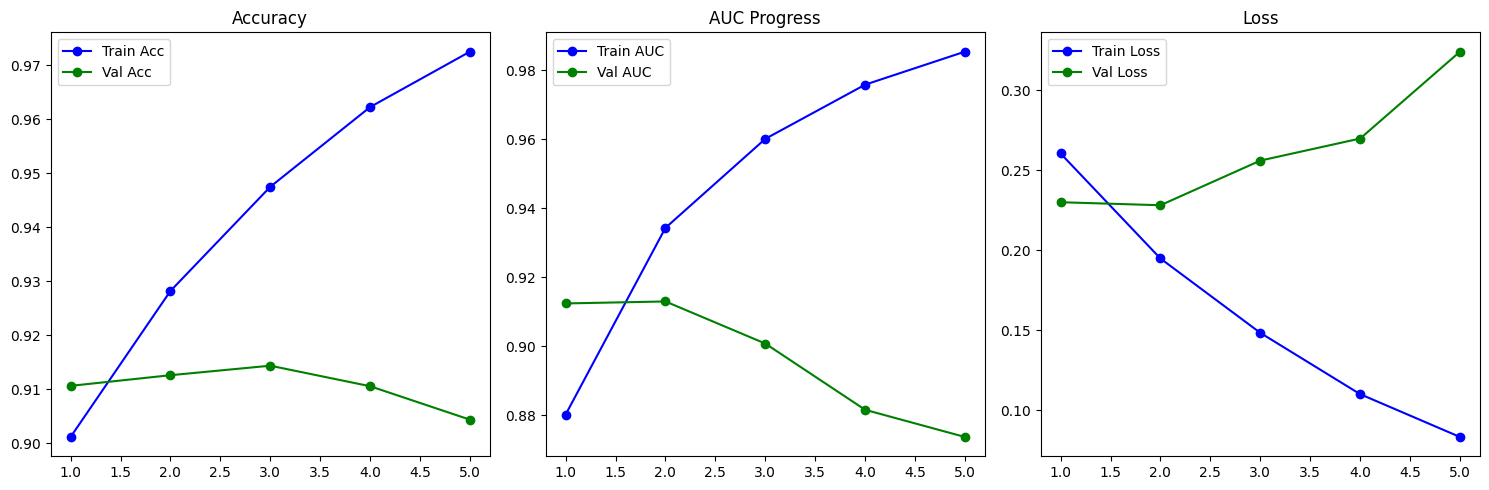

In [ ]:
def plot_extended_history(history):
    # Pull the metrics you named in .compile()
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))

    # 1. Accuracy Plot
    plt.subplot(1, 3, 1)
    plt.plot(epochs, acc, 'b-o', label='Train Acc')
    plt.plot(epochs, val_acc, 'g-o', label='Val Acc')
    plt.title('Accuracy')
    plt.legend()

    # 2. AUC Plot (New!)
    plt.subplot(1, 3, 2)
    plt.plot(epochs, auc, 'b-o', label='Train AUC')
    plt.plot(epochs, val_auc, 'g-o', label='Val AUC')
    plt.title('AUC Progress')
    plt.legend()

    # 3. Loss Plot
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history.history['loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], 'g-o', label='Val Loss')
    plt.title('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_extended_history(history)

445/445 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step


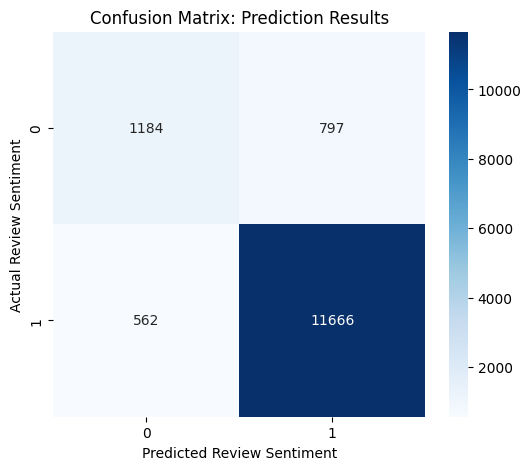

In [ ]:

# 1. Get the model's predictions (these will be probabilities like 0.82)
y_pred_probs = model.predict(X_test)

# 2. Converting probabilities to  0 or 1 (threshold of 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Calculate the matrix
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Prediction Results')
plt.ylabel('Actual Review Sentiment')
plt.xlabel('Predicted Review Sentiment')

plt.show()

In [ ]:
# Testing it withe xam sentence
my_review = ["This product was okay, but it broke after two days and the service was slow."]


seq = tokenizer.encode(my_review[0]).ids

seq_padded = pad_sequences([seq], maxlen=60)


prediction = model.predict(seq_padded)

print(f"Sentiment Score (0 to 1): {prediction[0][0]}")
print("Result: " + ("Positive" if prediction[0][0] > 0.5 else "Negative"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step
Sentiment Score (0 to 1): 0.9485761523246765
Result: Positive
